In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [3]:
df.shape

(43400, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [5]:
df.drop(columns= "id", inplace = True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,1462
smoking_status,13292


In [8]:
df["bmi"].describe()

,bmi
count,41938.000000
mean,28.605038
std,7.770020
min,10.100000
25%,23.200000
50%,27.700000
75%,32.900000
max,97.600000


In [9]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [10]:
df['smoking_status'] = df['smoking_status'].fillna("unknown")

In [11]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [12]:
categorical_unique_vals = {col: df[col].unique() for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']}
categorical_unique_vals


{'gender': array(['Male', 'Female', 'Other'], dtype=object),
 'ever_married': array(['No', 'Yes'], dtype=object),
 'work_type': array(['children', 'Private', 'Never_worked', 'Self-employed', 'Govt_job'],
       dtype=object),
 'Residence_type': array(['Rural', 'Urban'], dtype=object),
 'smoking_status': array(['unknown', 'never smoked', 'formerly smoked', 'smokes'],
       dtype=object)}

In [13]:
encoded_df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first= True, dtype= float)
encoded_df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes,smoking_status_unknown
0,3.0,0,0,95.12,18.0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,58.0,1,0,87.96,39.2,0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,8.0,0,0,110.89,17.6,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,70.0,0,0,69.04,35.9,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.0,0,0,161.28,19.1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          43400 non-null  float64
 1   hypertension                 43400 non-null  int64  
 2   heart_disease                43400 non-null  int64  
 3   avg_glucose_level            43400 non-null  float64
 4   bmi                          43400 non-null  float64
 5   stroke                       43400 non-null  int64  
 6   gender_Male                  43400 non-null  float64
 7   gender_Other                 43400 non-null  float64
 8   ever_married_Yes             43400 non-null  float64
 9   work_type_Never_worked       43400 non-null  float64
 10  work_type_Private            43400 non-null  float64
 11  work_type_Self-employed      43400 non-null  float64
 12  work_type_children           43400 non-null  float64
 13  Residence_type_U

In [15]:
encoded_df = pd.get_dummies(df, columns=['gender','ever_married','work_type','Residence_type','smoking_status'], drop_first=True, dtype=float)

In [16]:
target_col_vals = df['stroke'].value_counts()
target_col_vals

,count
stroke,
0,42617
1,783


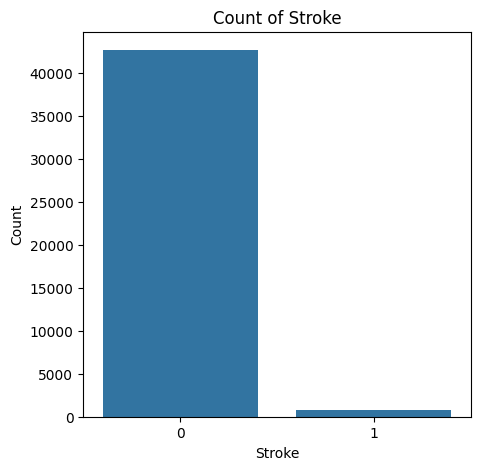

In [17]:
#plot the 'stroke' features value counts
plt.figure(figsize=(5,5))
sns.countplot(x=df['stroke'])
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Count of Stroke')
plt.show()

In [18]:
x = encoded_df.drop(columns= 'stroke')
y = encoded_df['stroke']

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify= y)

In [20]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
x_train = x_train.copy()
x_test = x_test.copy()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [21]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_smote, y_train_smote)
y_pred = lr.predict(x_test)

In [23]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7423963133640553
Precision Score: 0.05328749462827675
Recall Score: 0.7898089171974523
F1 Score: 0.0998389694041868
[[6320 2203]
 [  33  124]]
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      8523
           1       0.05      0.79      0.10       157

    accuracy                           0.74      8680
   macro avg       0.52      0.77      0.47      8680
weighted avg       0.98      0.74      0.84      8680



In [78]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_smote, y_train_smote)
y_pred = svc.predict(x_test)

In [79]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8067972350230415
Precision Score: 0.052941176470588235
Recall Score: 0.5732484076433121
F1 Score: 0.09693053311793215
[[6913 1610]
 [  67   90]]
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      8523
           1       0.05      0.57      0.10       157

    accuracy                           0.81      8680
   macro avg       0.52      0.69      0.49      8680
weighted avg       0.97      0.81      0.88      8680



In [24]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_smote, y_train_smote)
y_pred = xgb.predict(x_test)

In [25]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred)}")
print(f"Recall Score: {recall_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9737327188940093
Precision Score: 0.07228915662650602
Recall Score: 0.03821656050955414
F1 Score: 0.05
[[8446   77]
 [ 151    6]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8523
           1       0.07      0.04      0.05       157

    accuracy                           0.97      8680
   macro avg       0.53      0.51      0.52      8680
weighted avg       0.97      0.97      0.97      8680



In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

print(f"Best Hyperparameters for Logistic Regression: {grid_lr.best_params_}")
y_pred_grid_lr = grid_lr.predict(x_test)



Best Hyperparameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [27]:
print("\n--- Tuned Logistic Regression Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_grid_lr)}")
print(f"Precision Score: {precision_score(y_test, y_pred_grid_lr)}")
print(f"Recall Score: {recall_score(y_test, y_pred_grid_lr)}")
print(f"F1 Score: {f1_score(y_test, y_pred_grid_lr)}")
print(confusion_matrix(y_test, y_pred_grid_lr))
print(classification_report(y_test, y_pred_grid_lr))


--- Tuned Logistic Regression Evaluation ---
Accuracy Score: 0.7434331797235023
Precision Score: 0.05426356589147287
Recall Score: 0.802547770700637
F1 Score: 0.10165389269866881
[[6327 2196]
 [  31  126]]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      8523
           1       0.05      0.80      0.10       157

    accuracy                           0.74      8680
   macro avg       0.52      0.77      0.48      8680
weighted avg       0.98      0.74      0.84      8680



In [ ]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'scale_pos_weight': [54]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid_xgb,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

print(f"Best Hyperparameters for XGBoost: {grid_xgb.best_params_}")
y_pred_grid_xgb = grid_xgb.predict(x_test)


In [87]:
print("\n--- Tuned XGBoost Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_grid_xgb)}")
print(f"Precision Score: {precision_score(y_test, y_pred_grid_xgb)}")
print(f"Recall Score: {recall_score(y_test, y_pred_grid_xgb)}")
print(f"F1 Score: {f1_score(y_test, y_pred_grid_xgb)}")
print(confusion_matrix(y_test, y_pred_grid_xgb))
print(classification_report(y_test, y_pred_grid_xgb))


--- Tuned XGBoost Evaluation ---
Accuracy Score: 0.8783410138248848
Precision Score: 0.05801376597836775
Recall Score: 0.37579617834394907
F1 Score: 0.10051107325383304
[[7565  958]
 [  98   59]]
              precision    recall  f1-score   support

           0       0.99      0.89      0.93      8523
           1       0.06      0.38      0.10       157

    accuracy                           0.88      8680
   macro avg       0.52      0.63      0.52      8680
weighted avg       0.97      0.88      0.92      8680



In [88]:
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svc = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=42),
    param_grid=param_grid_svc,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)

grid_svc.fit(x_train, y_train)
print(f"Best Hyperparameters for SVC: {grid_svc.best_params_}")
y_pred_grid_svc = grid_svc.predict(x_test)


Best Hyperparameters for SVC: {'C': 1, 'kernel': 'rbf'}


In [89]:
print("\n--- Tuned SVC Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_grid_svc)}")
print(f"Precision Score: {precision_score(y_test, y_pred_grid_svc)}")
print(f"Recall Score: {recall_score(y_test, y_pred_grid_svc)}")
print(f"F1 Score: {f1_score(y_test, y_pred_grid_svc)}")
print(confusion_matrix(y_test, y_pred_grid_svc))
print(classification_report(y_test, y_pred_grid_svc))


--- Tuned SVC Evaluation ---
Accuracy Score: 0.7669354838709678
Precision Score: 0.052732502396931925
Recall Score: 0.7006369426751592
F1 Score: 0.09808292465448061
[[6547 1976]
 [  47  110]]
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      8523
           1       0.05      0.70      0.10       157

    accuracy                           0.77      8680
   macro avg       0.52      0.73      0.48      8680
weighted avg       0.98      0.77      0.85      8680



In [29]:
import pickle

X_full = encoded_df.drop(columns='stroke')
y_full = encoded_df['stroke']

production_scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
X_full_scaled = X_full.copy()
X_full_scaled[num_cols] = production_scaler.fit_transform(X_full[num_cols])

production_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
production_model.fit(X_full_scaled, y_full)

with open('stroke_model.pkl', 'wb') as f:
    pickle.dump(production_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(production_scaler, f)